In [17]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/flights.csv.zip')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
# ============================================================
# BLOCK 1: IMPORTS + DATA LOADING + EDA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv('/content/drive/MyDrive/flights.csv.zip')
print("Shape:", df.shape)
df.head()

Shape: (5819079, 31)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
# ============================================================
# STEP 1: UNDERSTANDING THE MISSING VALUES
# ============================================================

print("=== Missing Values ===")
print(df.isnull().sum()) #how many values are missing per column

print("\n=== Column Types ===")
print(df.dtypes) #shows datatype of each column
#shows which column needs encoding

print("\n=== Basic Stats ===")
print(df.describe())

=== Missing Values ===
YEAR                         0
MONTH                        0
DAY                          0
DAY_OF_WEEK                  0
AIRLINE                      0
FLIGHT_NUMBER                0
TAIL_NUMBER              14721
ORIGIN_AIRPORT               0
DESTINATION_AIRPORT          0
SCHEDULED_DEPARTURE          0
DEPARTURE_TIME           86153
DEPARTURE_DELAY          86153
TAXI_OUT                 89047
WHEELS_OFF               89047
SCHEDULED_TIME               6
ELAPSED_TIME            105071
AIR_TIME                105071
DISTANCE                     0
WHEELS_ON                92513
TAXI_IN                  92513
SCHEDULED_ARRIVAL            0
ARRIVAL_TIME             92513
ARRIVAL_DELAY           105071
DIVERTED                     0
CANCELLED                    0
CANCELLATION_REASON    5729195
AIR_SYSTEM_DELAY       4755640
SECURITY_DELAY         4755640
AIRLINE_DELAY          4755640
LATE_AIRCRAFT_DELAY    4755640
WEATHER_DELAY          4755640
dtype: int64

==

In [20]:
# ============================================================
# STEP 2: HANDLE MISSING VALUES (Correct Order)
# ============================================================

# ── First, understand what we're dealing with ────────────────
print("=== Before Cleaning ===")
print(f"Total rows: {len(df)}")
print(f"Cancelled flights:  {(df['CANCELLED'] == 1).sum()}")
print(f"Diverted flights:   {(df['DIVERTED'] == 1).sum()}")
print(f"ARRIVAL_DELAY NaN:  {df['ARRIVAL_DELAY'].isna().sum()}")

# ── Step 2a: Remove cancelled flights FIRST ──────────────────
# Cancelled = flight never departed
# These have ARRIVAL_DELAY = NaN but they're NOT "on time"
# They're a completely separate problem — don't mix them in
df = df[df['CANCELLED'] == 0].copy()

print(f"\nAfter removing cancelled: {len(df)} rows")
print(f"ARRIVAL_DELAY NaN now:    {df['ARRIVAL_DELAY'].isna().sum()}")

# ── Step 2b: Remove diverted flights ─────────────────────────
# Diverted = landed at wrong airport
# Example: JFK→LAX flight lands in PHX due to bad weather
# ARRIVAL_DELAY = NaN because it never reached intended destination
# Again — separate problem, don't mix in
df = df[df['DIVERTED'] == 0].copy()

print(f"After removing diverted:  {len(df)} rows")
print(f"ARRIVAL_DELAY NaN now:    {df['ARRIVAL_DELAY'].isna().sum()}")

# ── Step 2c: NOW fill remaining NaN in ARRIVAL_DELAY ─────────
# At this point every remaining row = flight that:
#   ✅ Actually departed
#   ✅ Actually landed at correct destination
# So remaining NaNs are ONLY data recording errors
# Filling with 0 is now safe — 0 means exactly one thing: on time
df['ARRIVAL_DELAY'] = df['ARRIVAL_DELAY'].fillna(0)

print(f"ARRIVAL_DELAY NaN now:    {df['ARRIVAL_DELAY'].isna().sum()}")
# Should print 0

# ── Step 2d: Drop rows missing core scheduling info ──────────
# We cannot predict delay WITHOUT these columns
# so we DROP rows where they are missing
# defensive programming, in our dataset no missing value for these two columns
before = len(df)
df.dropna(subset=['SCHEDULED_DEPARTURE', 'DISTANCE'], inplace=True)
after = len(df)

print(f"\nDropped {before - after} rows with missing scheduling info")

# ── Step 2e: Verify ARRIVAL_DELAY = 0 is now clean ───────────
print("\n=== ARRIVAL_DELAY value breakdown ===")
print(f"Exactly 0 (on time):     {(df['ARRIVAL_DELAY'] == 0).sum()}")
print(f"Positive (late):         {(df['ARRIVAL_DELAY'] > 0).sum()}")
print(f"Negative (early):        {(df['ARRIVAL_DELAY'] < 0).sum()}")
print(f"NaN remaining:           {df['ARRIVAL_DELAY'].isna().sum()}")

print(f"\n=== Final Shape ===")
print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")


=== Before Cleaning ===
Total rows: 5819079
Cancelled flights:  89884
Diverted flights:   15187
ARRIVAL_DELAY NaN:  105071

After removing cancelled: 5729195 rows
ARRIVAL_DELAY NaN now:    15187
After removing diverted:  5714008 rows
ARRIVAL_DELAY NaN now:    0
ARRIVAL_DELAY NaN now:    0

Dropped 0 rows with missing scheduling info

=== ARRIVAL_DELAY value breakdown ===
Exactly 0 (on time):     126213
Positive (late):         2086896
Negative (early):        3500899
NaN remaining:           0

=== Final Shape ===
Rows: 5714008
Columns: 31


In [21]:
# ============================================================
# STEP 3: CLEANING
# ============================================================

#CANCELLED column after filtering:  all values = 0
#DIVERTED  column after filtering:  all values = 0

#A column with only one unique value
#teaches the model absolutely nothing
#It's just dead weight in memory

In [22]:
# These columns leak future information or are irrelevant:
df.drop(columns=[
    'CANCELLED',
    'DIVERTED',
    'CANCELLATION_REASON',  # 99% NaN, irrelevant
    'AIR_SYSTEM_DELAY',     # only known AFTER flight lands
    'SECURITY_DELAY',       # only known AFTER flight lands
    'AIRLINE_DELAY',        # only known AFTER flight lands
    'LATE_AIRCRAFT_DELAY',  # only known AFTER flight lands
    'WEATHER_DELAY',        # only known AFTER flight lands
    'ARRIVAL_TIME',         # only known AFTER flight lands
    'WHEELS_ON',            # only known AFTER flight lands
    'TAXI_IN',              # only known AFTER flight lands
    'ELAPSED_TIME',         # only known AFTER flight lands
    'AIR_TIME',             # only known AFTER flight lands
], inplace=True)

print(f"Columns remaining: {len(df.columns)}")


Columns remaining: 18


In [23]:
#AIR_SYSTEM_DELAY, SECURITY_DELAY, AIRLINE_DELAY
#LATE_AIRCRAFT_DELAY, WEATHER_DELAY

#These tell you WHY a flight was delayed
#But you only know WHY after it already landed

In [24]:
# ============================================================
# STEP 4: TARGET VARIABLE
# ============================================================

# FAA official definition of delay = 15+ minutes late
# Using > 0 is too noisy (2 min late isn't operationally a delay), also we're referring FAA's definition
df['DELAYED'] = (df['ARRIVAL_DELAY'] > 15).astype(int)

print("=== Target Variable Distribution ===")
print(df['DELAYED'].value_counts())
print(f"\nDelay rate: {df['DELAYED'].mean():.1%}")

=== Target Variable Distribution ===
DELAYED
0    4690510
1    1023498
Name: count, dtype: int64

Delay rate: 17.9%


In [25]:
# ============================================================
# STEP 5: FEATURE ENGINEERING (Leakage-safe version)
# ============================================================

# ── Time features ─────────────────────────────────────────────
df['HOUR'] = df['SCHEDULED_DEPARTURE'] // 100
df['IS_WEEKEND'] = df['DAY_OF_WEEK'].isin([6, 7]).astype(int)
df['IS_MORNING'] = (df['HOUR'] < 10).astype(int)
df['IS_NIGHT'] = (df['HOUR'] >= 20).astype(int)

# ── Route feature ──────────────────────────────────────────────
df['ROUTE'] = df['ORIGIN_AIRPORT'].astype(str) + '_' + df['DESTINATION_AIRPORT'].astype(str)

# ── Encode categoricals (store each encoder separately) ────────
# We store encoders in a dict so we can reuse them later
# e.g. for inverse_transform or encoding new unseen data
encoders = {}
for col in ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'ROUTE']:
    encoders[col] = LabelEncoder()
    df[col] = encoders[col].fit_transform(df[col].astype(str))

print("=== After Encoding ===")
print(df[['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'ROUTE']].head())
print(f"\n=== Shape after Step 5 ===")
print(df.shape)



=== After Encoding ===
   AIRLINE  ORIGIN_AIRPORT  DESTINATION_AIRPORT  ROUTE
0        1             323                  584   4014
1        0             482                  542   6361
2       11             584                  373   8044
3        0             482                  510   6349
4        1             583                  324   7958

=== Shape after Step 5 ===
(5714008, 24)


In [26]:
# ============================================================
# STEP 6: TRAIN/TEST SPLIT
# ============================================================

# Features we'll use for prediction
# These are all things known BEFORE the flight departs
features = [
    'MONTH', 'DAY_OF_WEEK', 'DAY',
    'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'ROUTE',
    'SCHEDULED_DEPARTURE', 'HOUR', 'IS_WEEKEND', 'IS_MORNING', 'IS_NIGHT',
    'SCHEDULED_ARRIVAL', 'SCHEDULED_TIME', 'DISTANCE',
]

X = df[features]
y = df['DELAYED']

# stratify=y ensures both splits have the same delay rate
# e.g. if overall delay rate is 20%, train and test will both be ~20%
# without this, by random chance test could be 15% or 25% — unfair evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}")
print(f"Test size:  {len(X_test)}")
print(f"Train delay rate: {y_train.mean():.1%}")
print(f"Test delay rate:  {y_test.mean():.1%}")
# These two rates should be nearly identical — confirms stratify worked

Train size: 4571206
Test size:  1142802
Train delay rate: 17.9%
Test delay rate:  17.9%


In [27]:
# ============================================================
# STEP 7: TARGET ENCODING (After split — leakage-safe)
# ============================================================

# Why are we doing this here and not in Step 5?
# Because delay rates are computed FROM the target column (DELAYED)
# If we computed them on the full df, test rows would influence their own rates
# That's leakage — model sees hints of the answer during training
# Solution: compute rates ONLY from training data, then apply to both

def add_delay_rates(X_train, X_test, y_train, group_col, new_col):
    # Step 1: Temporarily attach y_train to X_train so we can group by feature + count delays
    # We use .copy() to avoid modifying the original X_train
    rate_map = X_train[[group_col]].copy()
    rate_map['DELAYED'] = y_train.values
    # y_train.values strips the pandas index
    # without .values, pandas tries to align by index and can produce NaNs

    # Step 2: Compute mean delay rate per group
    # e.g. AIRLINE 0 → 0.21 means that airline is delayed 21% of the time
    rate_map = rate_map.groupby(group_col)['DELAYED'].mean()
    # rate_map is now a Series: {group_value: delay_rate}

    # Step 3: Map each row's group value to its delay rate
    # .map() looks up each value in rate_map and replaces it with the rate
    X_train[new_col] = X_train[group_col].map(rate_map)
    X_test[new_col]  = X_test[group_col].map(rate_map)
    # Test set uses TRAIN's rates — never its own labels

    # Step 4: Handle unseen categories
    # A route in test might not exist in train (e.g. rare or new route)
    # Those get NaN from .map() — we fill with overall training delay rate
    global_rate = y_train.mean()
    X_train[new_col] = X_train[new_col].fillna(global_rate)
    X_test[new_col]  = X_test[new_col].fillna(global_rate)


add_delay_rates(X_train, X_test, y_train, 'AIRLINE',        'AIRLINE_DELAY_RATE')
add_delay_rates(X_train, X_test, y_train, 'ROUTE',          'ROUTE_DELAY_RATE')
add_delay_rates(X_train, X_test, y_train, 'ORIGIN_AIRPORT', 'ORIGIN_DELAY_RATE')
add_delay_rates(X_train, X_test, y_train, 'HOUR',           'HOUR_DELAY_RATE')

print("=== Delay Rate Features (Train sample) ===")
print(X_train[['AIRLINE_DELAY_RATE', 'ROUTE_DELAY_RATE',
               'ORIGIN_DELAY_RATE',  'HOUR_DELAY_RATE']].head())

=== Delay Rate Features (Train sample) ===
         AIRLINE_DELAY_RATE  ROUTE_DELAY_RATE  ORIGIN_DELAY_RATE  \
4041748            0.175518          0.209375           0.224531   
4762608            0.199659          0.093117           0.124637   
698375             0.130088          0.170139           0.196021   
4857417            0.210298          0.200000           0.092888   
5131332            0.130088          0.158097           0.158554   

         HOUR_DELAY_RATE  
4041748         0.254776  
4762608         0.250481  
698375          0.122779  
4857417         0.250481  
5131332         0.157596  


scale_pos_weight: 4.58
Training... (this will take a few minutes)
[0]	validation_0-auc:0.65297
[50]	validation_0-auc:0.69285
[100]	validation_0-auc:0.70567
[150]	validation_0-auc:0.71310
[200]	validation_0-auc:0.71738
[250]	validation_0-auc:0.72162
[299]	validation_0-auc:0.72415
Training complete.
=== Classification Report ===
              precision    recall  f1-score   support

     On Time       0.90      0.67      0.77    938102
     Delayed       0.30      0.66      0.42    204700

    accuracy                           0.66   1142802
   macro avg       0.60      0.66      0.59   1142802
weighted avg       0.79      0.66      0.70   1142802


AUC-ROC Score: 0.7242

=== Confusion Matrix ===
Predicted       0       1      All
Actual                            
0          623953  314149   938102
1           68758  135942   204700
All        692711  450091  1142802

=== Top 10 Most Important Features ===
ROUTE_DELAY_RATE       0.240718
HOUR_DELAY_RATE        0.200791
SCHEDULED_DEPART

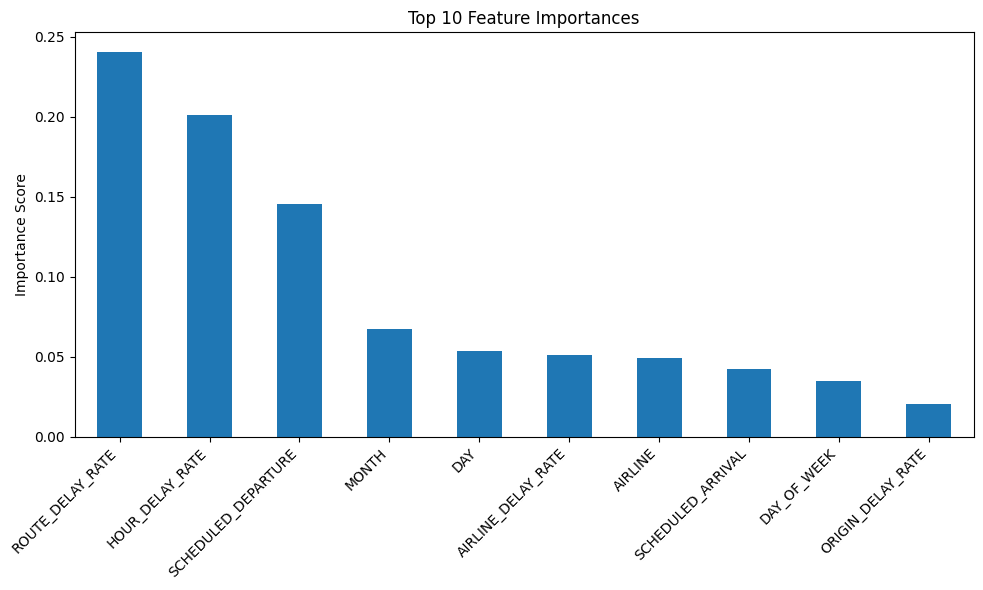

Model saved to Google Drive.


In [28]:
# ============================================================
# STEP 8: MODEL TRAINING
# ============================================================

# Why XGBoost?
# - Handles large datasets efficiently (4.5M rows is no problem)
# - Built-in handling for imbalanced classes via scale_pos_weight
# - Much faster than sklearn's GradientBoostingClassifier
# - Generally best out-of-the-box performance for tabular data

# scale_pos_weight handles class imbalance
# formula: count of negatives / count of positives
# e.g. if 82% non-delayed and 18% delayed → 82/18 ≈ 4.6
# this tells the model to penalize missing a delayed flight ~4.6x more
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f"scale_pos_weight: {scale:.2f}")

model = xgb.XGBClassifier(
    n_estimators=300,        # number of trees
    max_depth=6,             # how deep each tree grows — 6 is a safe default
    learning_rate=0.1,       # how much each tree corrects the previous one
    scale_pos_weight=scale,  # handles class imbalance
    use_label_encoder=False,
    eval_metric='auc',       # monitor AUC during training
    random_state=42,
    n_jobs=-1                # use all CPU cores
)

print("Training... (this will take a few minutes)")
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],  # monitor performance on test set each round
    verbose=50                     # print progress every 50 trees
)

print("Training complete.")

# ============================================================
# STEP 9: EVALUATION
# ============================================================

# Get predictions
y_pred       = model.predict(X_test)         # 0 or 1
y_pred_proba = model.predict_proba(X_test)[:, 1]  # probability of delay (0.0 to 1.0)

# ── Classification Report ─────────────────────────────────────
# Precision: of flights we predicted delayed, how many actually were?
# Recall:    of flights that were actually delayed, how many did we catch?
# F1:        harmonic mean of precision and recall
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['On Time', 'Delayed']))

# ── AUC-ROC ───────────────────────────────────────────────────
# Measures how well model separates delayed vs on-time across ALL thresholds
# 0.5 = random guessing, 1.0 = perfect
# Anything above 0.75 is solid for this problem
auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nAUC-ROC Score: {auc:.4f}")

# ── Confusion Matrix ──────────────────────────────────────────
# Shows exactly where the model is getting confused
cm = pd.crosstab(
    y_test, y_pred,
    rownames=['Actual'],
    colnames=['Predicted'],
    margins=True
)
print("\n=== Confusion Matrix ===")
print(cm)

# ── Feature Importance ────────────────────────────────────────
# Which features did the model rely on most?
importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("\n=== Top 10 Most Important Features ===")
print(importance.head(10))

# Plot it
plt.figure(figsize=(10, 6))
importance.head(10).plot(kind='bar')
plt.title('Top 10 Feature Importances')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
import joblib
joblib.dump(model, '/content/drive/MyDrive/flight_delay_model.joblib')
print("Model saved to Google Drive.")

In [29]:
import joblib

artifacts = {
    'model': model,
    'encoders': encoders,
    'features': features
}

joblib.dump(artifacts, '/content/drive/MyDrive/flight_delay_artifacts.joblib')
print("Saved.")

Saved.


In [32]:
joblib.dump(artifacts, '/content/drive/MyDrive/flight_delay_artifacts.joblib')

# Load (new session)
drive.mount('/content/drive')
artifacts = joblib.load('/content/drive/MyDrive/flight_delay_artifacts.joblib')
model    = artifacts['model']
encoders = artifacts['encoders']
features = artifacts['features']

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
